# PediTrack RAG — GPU Accelerated Dataset Ingestion (Full Re-ingest)

This notebook ingests **all** pediatric datasets into a FAISS vector store using GPU acceleration.

### Datasets included

**Remote / Processed datasets** (uploaded as `processed_data.zip`):
| Dataset | Docs |
|---|---|
| HealthCareMagic | 24,855 |
| Medical QA Pediatric | 6,500 |
| Symptom Checker + Disease DB | 11,502 |
| PediatricsMQA | 3,417 |

**Local / Sri Lanka datasets** (uploaded as `datasets_local.zip`):
| Dataset | Source |
|---|---|
| CDC.json | National Child Development Centre Guidelines (SL) |
| CHDR.json | Child Health & Development Record (SL) |
| FEMALE_GROWTH_CHDR.json | Female Growth Chart — CHDR (SL) |
| MALE_GROWTH_CHDR.json | Male Growth Chart — CHDR (SL) |
| IYCF.json | Infant & Young Child Feeding Guidelines (SL) |
| SL_Nutrition.json | Sri Lanka Nutrition Guidelines |
| SL_FOOD_GUIDE.json | Sri Lanka Complementary Feeding Guide |
| UNICEF_PARENTING.json | UNICEF Parenting Guide |

**Online datasets** (fetched automatically from HuggingFace / GitHub in Step 3b):
| Dataset | Source | Notes |
|---|---|---|
| MedDialog-EN | HuggingFace `bigbio/meddialog` | English doctor-patient dialogues |
| MedSynth | HuggingFace `Ahmad0067/MedSynth` | Synthetic medical QA |
| MTS-Dialog | GitHub `abachaa/MTS-Dialog` | Doctor-patient + clinical notes |
| MediTOD | HuggingFace (if released) | Task-oriented medical dialogues |
| HyperAI Medical-Dialogue | Manual download only | Mainly Chinese, skipped |

**Grand Total: ~46,274 + local + online docs**

## Step 1: Setup Environment

In [4]:
# Check GPU availability
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("⚠️ No GPU detected. Make sure to enable GPU in Runtime > Change runtime type")

CUDA available: True
GPU: Tesla T4
GPU Memory: 14.56 GB


In [5]:
# Install required packages
!pip install -q sentence-transformers numpy tqdm
!pip install -q umap-learn matplotlib seaborn
!pip install -q datasets   # HuggingFace datasets (for online sources)

# faiss-gpu-cu12 is the correct package for Colab T4 (CUDA 12)
!pip install -q faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 23.8 MB/s eta 0:00:00


---
## Step 2: Upload Processed Data (remote datasets)

Upload the `processed_data.zip` file from your local machine.
This should contain the `processed/` folder with the 4 remote dataset JSONs.

In [6]:
from google.colab import files
import zipfile
from pathlib import Path

print("Please upload  processed_data.zip")
uploaded = files.upload()

with zipfile.ZipFile('processed_data.zip', 'r') as zf:
    zf.extractall('.')

print("✓ processed_data.zip extracted")

pfiles = list(Path('processed').glob('*_processed.json'))
pfiles = [f for f in pfiles if 'combined' not in f.name.lower()]
print(f"  Found {len(pfiles)} processed dataset files:")
for f in pfiles:
    print(f"    - {f.name}")

Please upload  processed_data.zip


Saving processed_data.zip to processed_data.zip
✓ processed_data.zip extracted
  Found 3 processed dataset files:
    - healthcaremagic_processed.json
    - medical_qa_pediatric_processed.json
    - pediatricsmqa_processed.json


---
## Step 3: Upload Local Sri Lanka Datasets

Zip the `datasets-local/` folder and upload it here.

**How to zip on Windows (run in PowerShell from the repo root):**
```powershell
Compress-Archive -Path 'services\peditrack-rag-service\datasets-local\*' -DestinationPath 'datasets_local.zip'
```

Upload the resulting `datasets_local.zip` below.

In [7]:
from google.colab import files
import zipfile, os
from pathlib import Path

print("Please upload  datasets_local.zip")
uploaded_local = files.upload()

os.makedirs('datasets_local', exist_ok=True)
with zipfile.ZipFile('datasets_local.zip', 'r') as zf:
    zf.extractall('datasets_local')

print("✓ datasets_local.zip extracted")

local_files = list(Path('datasets_local').glob('*.json'))
print(f"  Found {len(local_files)} local dataset files:")
for f in local_files:
    print(f"    - {f.name}")

Please upload  datasets_local.zip


Saving datasets_local.zip to datasets_local.zip
✓ datasets_local.zip extracted
  Found 8 local dataset files:
    - IYCF.json
    - CDC.json
    - CHDR.json
    - MALE_GROWTH_CHDR.json
    - UNICEF_PARENTING.json
    - SL_FOOD_GUIDE.json
    - FEMALE_GROWTH_CHDR.json
    - SL_Nutrition.json


---
## Step 3b: Fetch Additional Online Datasets

These are pulled **automatically** from HuggingFace / GitHub — no manual upload needed.

| Dataset | Where | Status |
|---|---|---|
| MedDialog-EN | HuggingFace `bigbio/meddialog` | ✅ auto |
| MedSynth | HuggingFace `Ahmad0067/MedSynth` | ✅ auto |
| MTS-Dialog | GitHub `abachaa/MTS-Dialog` | ✅ auto |
| MediTOD | HuggingFace (if released post-EMNLP 2024) | ⚠️ tries, skips if unavailable |
| HyperAI Medical-Dialogue | Mainly Chinese, manual only | ⏭ skipped |

> Set `PEDIATRIC_FILTER = True` to keep only records mentioning children/infants.  
> Set `PEDIATRIC_FILTER = False` to ingest all records (more coverage, larger index).

In [8]:
from datasets import load_dataset
import subprocess, csv, glob, re, os

# ── Config ────────────────────────────────────────────────────────────────────
PEDIATRIC_FILTER = False    # True = keep only records mentioning children/infants
MAX_CHUNK_CHARS  = 600      # Hard cap per stored chunk; 0 = no limit

PEDIATRIC_KEYWORDS = [
    'child','baby', 'toddler', 'pediatric', 'paediatric',
    'kid', 'children',
]

# ── Curation helpers ──────────────────────────────────────────────────────────

def passes_filter(text: str) -> bool:
    if not PEDIATRIC_FILTER:
        return True
    t = text.lower()
    return any(kw in t for kw in PEDIATRIC_KEYWORDS)

def clean_text(text: str) -> str:
    """Strip HTML/XML tags and collapse whitespace."""
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def chunk_text(text: str, max_chars: int = MAX_CHUNK_CHARS):
    """
    Split at sentence boundaries so each chunk ≤ max_chars.
    Falls back to hard truncation for sentences that exceed the limit.
    """
    if not max_chars or len(text) <= max_chars:
        return [text]
    sentences = re.split(r'(?<=[.!?])\s+', text)
    chunks, current = [], ''
    for sent in sentences:
        if len(current) + len(sent) + 1 <= max_chars:
            current = (current + ' ' + sent).strip() if current else sent
        else:
            if current:
                chunks.append(current)
            current = sent[:max_chars]   # hard-truncate single overlong sentence
    if current:
        chunks.append(current)
    return chunks or [text[:max_chars]]

def add_doc(docs, text, source, meta=None):
    """
    Clean → chunk → quality-gate → append to docs.
    Returns the number of chunks actually added.
    """
    text = clean_text(text)
    if not text or len(text) < 25:          # skip near-empty records
        return 0
    added = 0
    for chunk in chunk_text(text):
        if len(chunk) < 25:                  # skip tiny trailing chunks
            continue
        if passes_filter(chunk):
            docs.append({'text': chunk, 'source': source, 'metadata': meta or {}})
            added += 1
    return added


online_docs = []    # collected here, ingested into FAISS in Step 7b


# ── 1. MedDialog-EN ───────────────────────────────────────────────────────────
# Raw format: list of utterances, alternating patient / doctor turns.
# Curation   : extract consecutive (patient, doctor) PAIRS → one chunk each.
#              This keeps each chunk focused on one specific patient concern.
print("1/4  MedDialog-EN  (bigbio/meddialog) ...")
try:
    ds = load_dataset("bigbio/meddialog", "meddialog_en_source",
                      split="train", trust_remote_code=True)
    count = 0
    for item in ds:
        utterances = item.get('utterances', [])
        if not isinstance(utterances, list):
            utterances = [{'utterance': str(utterances)}]

        # Collect non-empty turn texts
        turns = []
        for u in utterances:
            utt = (u.get('utterance', '') if isinstance(u, dict) else str(u)).strip()
            if utt:
                turns.append(utt)

        # Pair turns: turns[0]+turns[1], turns[2]+turns[3], ...
        for i in range(0, len(turns) - 1, 2):
            patient_t = turns[i]
            doctor_t  = turns[i + 1]
            text = f"Patient: {patient_t} | Doctor: {doctor_t}"
            count += add_doc(online_docs, text, 'MedDialog_EN',
                             {'turn_pair': i // 2})

    print(f"   ✓ {count:,} Q-A pair chunks")
except Exception as e:
    print(f"   ✗ {e}")


# ── 2. MedSynth ───────────────────────────────────────────────────────────────
# Raw format: instruction-tuning style  {question/instruction, answer/output}.
# Curation   : format as "Q: … | A: …", skip records with trivially short answers.
print("2/4  MedSynth  (Ahmad0067/MedSynth) ...")
try:
    ds = load_dataset("Ahmad0067/MedSynth", split="train", trust_remote_code=True)
    count = 0
    for item in ds:
        q = (item.get('question')    or item.get('instruction') or
             item.get('input')       or '').strip()
        a = (item.get('answer')      or item.get('output')      or
             item.get('response')    or '').strip()

        if not q or not a or len(a) < 20:   # skip empty / one-word answers
            continue

        text = f"Q: {q} | A: {a}"
        count += add_doc(online_docs, text, 'MedSynth')

    print(f"   ✓ {count:,} Q-A chunks")
except Exception as e:
    print(f"   ✗ {e}")


# ── 3. MTS-Dialog ─────────────────────────────────────────────────────────────
# Raw format: CSV with a full dialogue transcript + optional clinical note.
# Curation   : split dialogue into speaker turns (by newline/double-space),
#              pair consecutive turns → one chunk each.
#              Clinical note stored as a separate chunk (valuable summary).
print("3/4  MTS-Dialog  (GitHub abachaa/MTS-Dialog) ...")
try:
    subprocess.run(
        ['git', 'clone', '--depth', '1', 'https://github.com/abachaa/MTS-Dialog.git'],
        capture_output=True, text=True
    )
    csv_files = glob.glob('MTS-Dialog/**/*.csv', recursive=True)
    count = 0
    for fp in csv_files:
        with open(fp, encoding='utf-8', errors='replace') as f:
            reader = csv.DictReader(f)
            for row in reader:
                dialogue = (row.get('dialogue') or row.get('Dialogue') or
                            row.get('conversation') or '').strip()
                note     = (row.get('note') or row.get('Note') or
                            row.get('summary') or '').strip()

                # Split transcript into individual speaker turns
                turns = [t.strip() for t in re.split(r'\n|  +', dialogue) if t.strip()]

                if len(turns) >= 2:
                    # Pair consecutive turns → focused Q&A-style chunks
                    for i in range(0, len(turns) - 1, 2):
                        pair = turns[i]
                        if i + 1 < len(turns):
                            pair += f" | {turns[i + 1]}"
                        count += add_doc(online_docs, pair, 'MTS_Dialog',
                                         {'turn_pair': i // 2})
                else:
                    # Fallback: whole dialogue as single (auto-chunked) text
                    count += add_doc(online_docs, dialogue, 'MTS_Dialog')

                # Clinical note → separate doc (dense medical summary = high-value chunk)
                if note:
                    count += add_doc(online_docs,
                                     f"Clinical note: {note}", 'MTS_Dialog',
                                     {'type': 'clinical_note'})

    print(f"   ✓ {count:,} chunks  ({len(csv_files)} CSV files)")
except Exception as e:
    print(f"   ✗ {e}")


# ── 4. MediTOD ────────────────────────────────────────────────────────────────
# Raw format: task-oriented dialogue (list of turns or flat string).
# Curation   : same pair strategy as MedDialog/MTS-Dialog.
print("4/4  MediTOD  (EMNLP 2024) ...")
try:
    loaded = False
    for hf_handle in ["abachaa/meditod", "meditod/meditod", "abachaa/MediTOD"]:
        try:
            ds = load_dataset(hf_handle, split="train", trust_remote_code=True)
            count = 0
            for item in ds:
                raw = item.get('dialogue', item.get('text', item.get('utterance', '')))
                if isinstance(raw, list):
                    turns = [str(t).strip() for t in raw if str(t).strip()]
                    for i in range(0, len(turns) - 1, 2):
                        pair = turns[i]
                        if i + 1 < len(turns):
                            pair += f" | {turns[i + 1]}"
                        count += add_doc(online_docs, pair, 'MediTOD',
                                         {'turn_pair': i // 2})
                else:
                    count += add_doc(online_docs, str(raw), 'MediTOD')
            print(f"   ✓ {count:,} chunks from {hf_handle}")
            loaded = True
            break
        except Exception:
            continue
    if not loaded:
        print("   ✗ Not yet published on HuggingFace")
        print("     → https://aclanthology.org/2024.emnlp-main.936/")
except Exception as e:
    print(f"   ✗ {e}")


# ── 5. HyperAI ────────────────────────────────────────────────────────────────
print("\nℹ  HyperAI Medical-Dialogue: mostly Chinese — skipped (manual download only)")

print(f"\n{'='*55}")
print(f"  Online datasets ready for ingestion: {len(online_docs):,} chunks")
print(f"{'='*55}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bigbio/meddialog' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'bigbio/meddialog' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


1/4  MedDialog-EN  (bigbio/meddialog) ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

meddialog.py: 0.00B [00:00, ?B/s]

...

MedSynth_huggingface_final.csv:   0%|          | 0.00/78.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10240 [00:00<?, ? examples/s]

   ✓ 0 Q-A chunks
3/4  MTS-Dialog  (GitHub abachaa/MTS-Dialog) ...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'abachaa/meditod' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'abachaa/meditod' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'meditod/meditod' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not suppor

   ✓ 33,106 chunks  (9 CSV files)
4/4  MediTOD  (EMNLP 2024) ...
   ✗ Not yet published on HuggingFace
     → https://aclanthology.org/2024.emnlp-main.936/

ℹ  HyperAI Medical-Dialogue: mostly Chinese — skipped (manual download only)

  Online datasets ready for ingestion: 33,106 chunks


---
## Step 4: Load Embedding Model (GPU)

In [9]:
from sentence_transformers import SentenceTransformer
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Loading model on {device}...")

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)
embedding_dim = 384

print(f"✓ Model loaded on {device}")
print(f"Embedding dimension: {embedding_dim}")

Loading model on cuda...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Model loaded on cuda
Embedding dimension: 384


---
## Step 5: Initialize FAISS Vector Store

In [10]:
import faiss
import numpy as np
import torch

index_cpu = faiss.IndexFlatL2(embedding_dim)

# Move index to GPU if available
if torch.cuda.is_available():
    res = faiss.StandardGpuResources()
    index = faiss.index_cpu_to_gpu(res, 0, index_cpu)
    print("✓ FAISS index on GPU")
else:
    index = index_cpu
    print("⚠️ FAISS index on CPU (no GPU found)")

metadata_list = []
dataset_labels = []
print(f"✓ FAISS index created (dimension: {embedding_dim})")

✓ FAISS index on GPU
✓ FAISS index created (dimension: 384)


---
## Step 6: Ingest Remote Processed Datasets

In [11]:
import json
from pathlib import Path
from tqdm.notebook import tqdm

processed_files = list(Path('processed').glob('*_processed.json'))
processed_files = [f for f in processed_files if 'combined' not in f.name.lower()]

print(f"Ingesting {len(processed_files)} remote processed datasets...\n")

total_docs_remote = 0
batch_size = 100

for processed_file in processed_files:
    dataset_label = processed_file.stem.replace('_processed', '')
    print(f"📥 {processed_file.name}")

    with open(processed_file, 'r', encoding='utf-8') as f:
        documents = json.load(f)

    print(f"   Documents: {len(documents):,}")

    for i in tqdm(range(0, len(documents), batch_size), desc="   Embedding"):
        batch = documents[i:i + batch_size]
        texts = [doc['text'] for doc in batch]
        embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
        index.add(embeddings.astype('float32'))
        for doc in batch:
            metadata_list.append({
                'text': doc['text'],
                'source': doc['source'],
                'metadata': doc.get('metadata', {})
            })
            dataset_labels.append(dataset_label)

    total_docs_remote += len(documents)
    print(f"   ✓ Ingested {len(documents):,} documents\n")

print(f"✅ Remote datasets total: {total_docs_remote:,} documents")
print(f"   Vector store size so far: {index.ntotal:,}")

Ingesting 3 remote processed datasets...

📥 healthcaremagic_processed.json
   Documents: 24,855


   Embedding:   0%|          | 0/249 [00:00<?, ?it/s]

   ✓ Ingested 24,855 documents

📥 medical_qa_pediatric_processed.json
   Documents: 6,500


   Embedding:   0%|          | 0/65 [00:00<?, ?it/s]

   ✓ Ingested 6,500 documents

📥 pediatricsmqa_processed.json
   Documents: 3,417


   Embedding:   0%|          | 0/35 [00:00<?, ?it/s]

   ✓ Ingested 3,417 documents

✅ Remote datasets total: 34,772 documents
   Vector store size so far: 34,772


---
## Step 7: Process & Ingest Local Sri Lanka Datasets

The local datasets use a nested `content` object instead of a flat `text` field.
We flatten all content fields into a single text string before embedding.

In [12]:
import json
from pathlib import Path
from tqdm.notebook import tqdm

# ─── helpers ──────────────────────────────────────────────────────────────────

def flatten_value(val, depth=0) -> str:
    """Recursively turn any JSON value into a human-readable string."""
    if isinstance(val, str):
        return val.strip()
    if isinstance(val, (int, float, bool)):
        return str(val)
    if isinstance(val, list):
        parts = [flatten_value(v, depth + 1) for v in val]
        return '. '.join(p for p in parts if p)
    if isinstance(val, dict):
        parts = []
        for k, v in val.items():
            key_label = k.replace('_', ' ').capitalize()
            parts.append(f"{key_label}: {flatten_value(v, depth + 1)}")
        return '. '.join(parts)
    return ''


def local_doc_to_text(doc: dict) -> str:
    """Convert a local dataset record to a flat text string for embedding."""
    parts = []
    if doc.get('source'):
        parts.append(f"Source: {doc['source']}")
    auth = doc.get('authority')
    if auth:
        parts.append("Authority: " + (', '.join(auth) if isinstance(auth, list) else auth))
    if doc.get('gender'):
        parts.append(f"Gender: {doc['gender']}")
    tags = doc.get('context_tags', [])
    if tags:
        parts.append('Topics: ' + ', '.join(t.replace('_', ' ') for t in tags))
    content = doc.get('content', {})
    if content:
        parts.append(flatten_value(content))
    return ' | '.join(parts)


# ─── source label map ─────────────────────────────────────────────────────────
SOURCE_LABELS = {
    'CDC.json':                'SL_CDC',
    'CHDR.json':               'SL_CHDR',
    'FEMALE_GROWTH_CHDR.json': 'SL_Female_Growth',
    'MALE_GROWTH_CHDR.json':   'SL_Male_Growth',
    'IYCF.json':               'SL_IYCF',
    'SL_Nutrition.json':       'SL_Nutrition',
    'SL_FOOD_GUIDE.json':      'SL_Food_Guide',
    'UNICEF_PARENTING.json':   'UNICEF_Parenting',
}

# ─── ingest ───────────────────────────────────────────────────────────────────
local_files = sorted(Path('datasets_local').glob('*.json'))
print(f"Ingesting {len(local_files)} local Sri Lanka datasets...\n")

total_docs_local = 0
batch_size = 64

for local_file in local_files:
    dataset_label = SOURCE_LABELS.get(local_file.name, local_file.stem)
    print(f"📥 {local_file.name}  →  {dataset_label}")

    with open(local_file, 'r', encoding='utf-8') as f:
        raw_docs = json.load(f)

    print(f"   Raw records: {len(raw_docs):,}")

    for i in tqdm(range(0, len(raw_docs), batch_size), desc="   Embedding"):
        batch = raw_docs[i:i + batch_size]
        texts = [local_doc_to_text(doc) for doc in batch]
        embeddings = model.encode(texts, convert_to_numpy=True, show_progress_bar=False)
        index.add(embeddings.astype('float32'))
        for doc, text in zip(batch, texts):
            metadata_list.append({
                'text': text,
                'source': dataset_label,
                'metadata': {
                    'id': doc.get('id', ''),
                    'lankan': doc.get('lankan', True),
                    'gender': doc.get('gender', ''),
                    'context_tags': doc.get('context_tags', [])
                }
            })
            dataset_labels.append(dataset_label)

    total_docs_local += len(raw_docs)
    print(f"   ✓ Ingested {len(raw_docs):,} documents\n")

print(f"✅ Local datasets total: {total_docs_local:,} documents")
print(f"   Vector store size so far: {index.ntotal:,}")

Ingesting 8 local Sri Lanka datasets...

📥 CDC.json  →  SL_CDC
   Raw records: 24


   Embedding:   0%|          | 0/1 [00:00<?, ?it/s]

   ✓ Ingested 24 documents

📥 CHDR.json  →  SL_CHDR
   Raw records: 96


   Embedding:   0%|          | 0/2 [00:00<?, ?it/s]

   ✓ Ingested 96 documents

📥 FEMALE_GROWTH_CHDR.json  →  SL_Female_Growth
   Raw records: 100


...

   ✓ Ingested 100 documents

📥 SL_Nutrition.json  →  SL_Nutrition
   Raw records: 65


   Embedding:   0%|          | 0/2 [00:00<?, ?it/s]

   ✓ Ingested 65 documents

📥 UNICEF_PARENTING.json  →  UNICEF_Parenting
   Raw records: 430


   Embedding:   0%|          | 0/7 [00:00<?, ?it/s]

   ✓ Ingested 430 documents

✅ Local datasets total: 965 documents
   Vector store size so far: 35,737


---
## Step 7b: Ingest Online Datasets

Batch-encode and add all documents from `online_docs` (MedDialog-EN, MedSynth, MTS-Dialog, MediTOD) into the FAISS index.

In [13]:
if not online_docs:
    print("No online documents to ingest — skipping Step 7b.")
else:
    BATCH = 512
    total_online = len(online_docs)
    added = 0

    for start in tqdm(range(0, total_online, BATCH), desc="Ingesting online datasets"):
        batch = online_docs[start : start + BATCH]
        texts = [d['text'] for d in batch]

        vecs = model.encode(texts, batch_size=BATCH,
                            show_progress_bar=False,
                            convert_to_numpy=True).astype('float32')

        index.add(vecs)

        for i, (d, vec) in enumerate(zip(batch, vecs)):
            metadata_list.append({
                'id':     index.ntotal - len(batch) + i,
                'text':   d['text'],
                'source': d['source'],
            })
            dataset_labels.append(d['source'])

        added += len(batch)

    print(f"✓ Step 7b complete — added {added:,} online documents")
    print(f"  FAISS index total: {index.ntotal:,} vectors")

Ingesting online datasets:   0%|          | 0/65 [00:00<?, ?it/s]

✓ Step 7b complete — added 33,106 online documents
  FAISS index total: 68,843 vectors


---
## Step 8: Ingestion Summary

In [14]:
from collections import Counter

label_counts = Counter(dataset_labels)

print("=" * 55)
print(" INGESTION SUMMARY")
print("=" * 55)
for label, count in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f"  {label:<35} {count:>6,} docs")
print("-" * 55)
print(f"  {'TOTAL':<35} {index.ntotal:>6,} vectors")
print("=" * 55)

 INGESTION SUMMARY
  MTS_Dialog                          33,106 docs
  healthcaremagic                     24,855 docs
  medical_qa_pediatric                 6,500 docs
  pediatricsmqa                        3,417 docs
  UNICEF_Parenting                       430 docs
  SL_Female_Growth                       100 docs
  SL_Male_Growth                         100 docs
  SL_Food_Guide                          100 docs
  SL_CHDR                                 96 docs
  SL_Nutrition                            65 docs
  SL_IYCF                                 50 docs
  SL_CDC                                  24 docs
-------------------------------------------------------
  TOTAL                               68,843 vectors


---
## Step 9: Save Vector Store

In [15]:
import json

# Convert GPU index back to CPU before saving
if torch.cuda.is_available():
    index_to_save = faiss.index_gpu_to_cpu(index)
else:
    index_to_save = index

# Save FAISS index
faiss.write_index(index_to_save, 'faiss_index')
print("✓ FAISS index saved")

# Save metadata
with open('metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata_list, f, ensure_ascii=False)
print("✓ Metadata saved")

print(f"\nFiles created:")
print(f"  faiss_index   — {index_to_save.ntotal:,} vectors")
print(f"  metadata.json — {len(metadata_list):,} entries")

✓ FAISS index saved
✓ Metadata saved

Files created:
  faiss_index   — 68,843 vectors
  metadata.json — 68,843 entries


---
## Step 10: 2D Vector Space Visualization

We use **UMAP** to project the 384-dimensional embeddings down to 2 dimensions and plot every document coloured by its source dataset.

> This lets you verify that semantically similar documents cluster together and that the Sri Lanka local datasets occupy meaningful regions in the shared space.

Total vectors in index: 68,843
✓ Vectors extracted
✓ Stratified sample: 7,994 points
Running UMAP  (≈ 1-2 min)...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✓ UMAP done


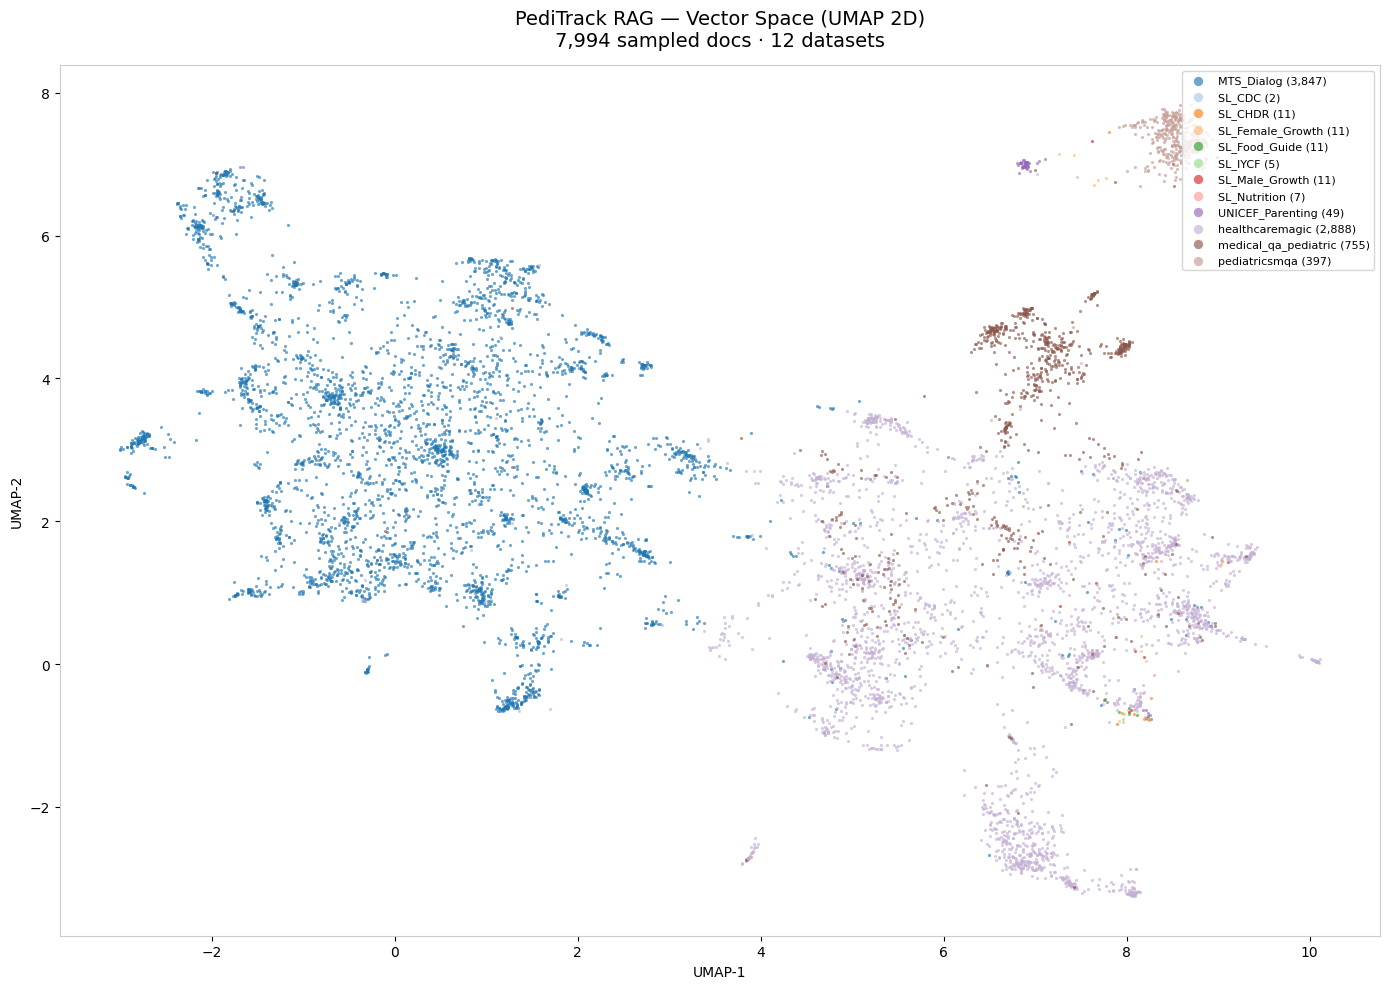

✓ Saved  vector_space_2d.png


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from collections import Counter

# ── 1. Extract all vectors from the FAISS index ──────────────────────────────
print(f"Total vectors in index: {index.ntotal:,}")

all_vecs = np.zeros((index_to_save.ntotal, embedding_dim), dtype='float32')
for i in range(index_to_save.ntotal):
    all_vecs[i] = index_to_save.reconstruct(i)
print("✓ Vectors extracted")

# ── 2. Stratified sample for speed (UMAP can be slow on 46k+ points) ─────────
#    Set MAX_SAMPLE = None to plot ALL points (takes longer)
MAX_SAMPLE = 8000

labels_arr = np.array(dataset_labels)

if MAX_SAMPLE and index.ntotal > MAX_SAMPLE:
    rng = np.random.default_rng(42)
    unique_lbs = list(set(dataset_labels))
    chosen_idx = []
    for lbl in unique_lbs:
        lbl_idx = np.where(labels_arr == lbl)[0]
        n = max(1, int(MAX_SAMPLE * len(lbl_idx) / index.ntotal))
        chosen_idx.extend(rng.choice(lbl_idx, size=min(n, len(lbl_idx)), replace=False).tolist())
    chosen_idx = np.array(chosen_idx)
    sample_vecs   = all_vecs[chosen_idx]
    sample_labels = labels_arr[chosen_idx]
    print(f"✓ Stratified sample: {len(chosen_idx):,} points")
else:
    sample_vecs   = all_vecs
    sample_labels = labels_arr
    print(f"✓ Using all {len(sample_vecs):,} points")

# ── 3. UMAP reduction to 2D ───────────────────────────────────────────────────
print("Running UMAP  (≈ 1-2 min)...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    random_state=42,
    verbose=False
)
embedding_2d = reducer.fit_transform(sample_vecs)
print("✓ UMAP done")

# ── 4. Plot ───────────────────────────────────────────────────────────────────
unique_labels_sorted = sorted(set(sample_labels))
palette   = sns.color_palette('tab20', n_colors=len(unique_labels_sorted))
color_map = {lbl: palette[i] for i, lbl in enumerate(unique_labels_sorted)}

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for lbl in unique_labels_sorted:
    mask = sample_labels == lbl
    ax.scatter(
        embedding_2d[mask, 0], embedding_2d[mask, 1],
        c=[color_map[lbl]], s=5, alpha=0.65, label=f"{lbl} ({mask.sum():,})", linewidths=0
    )

ax.legend(loc='upper right', fontsize=8, framealpha=0.8,
          facecolor='white', edgecolor='#cccccc', labelcolor='black', markerscale=3)

ax.set_title(
    f'PediTrack RAG — Vector Space (UMAP 2D)\n'
    f'{len(sample_labels):,} sampled docs · {len(unique_labels_sorted)} datasets',
    color='black', fontsize=14, pad=14
)
ax.set_xlabel('UMAP-1', color='black', fontsize=10)
ax.set_ylabel('UMAP-2', color='black', fontsize=10)
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_edgecolor('#cccccc')

plt.tight_layout()
plt.savefig('vector_space_2d.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved  vector_space_2d.png")

---
## Step 11: Per-Dataset Facet Grid

Same 2D space split into one subplot per dataset so clusters don't overlap.

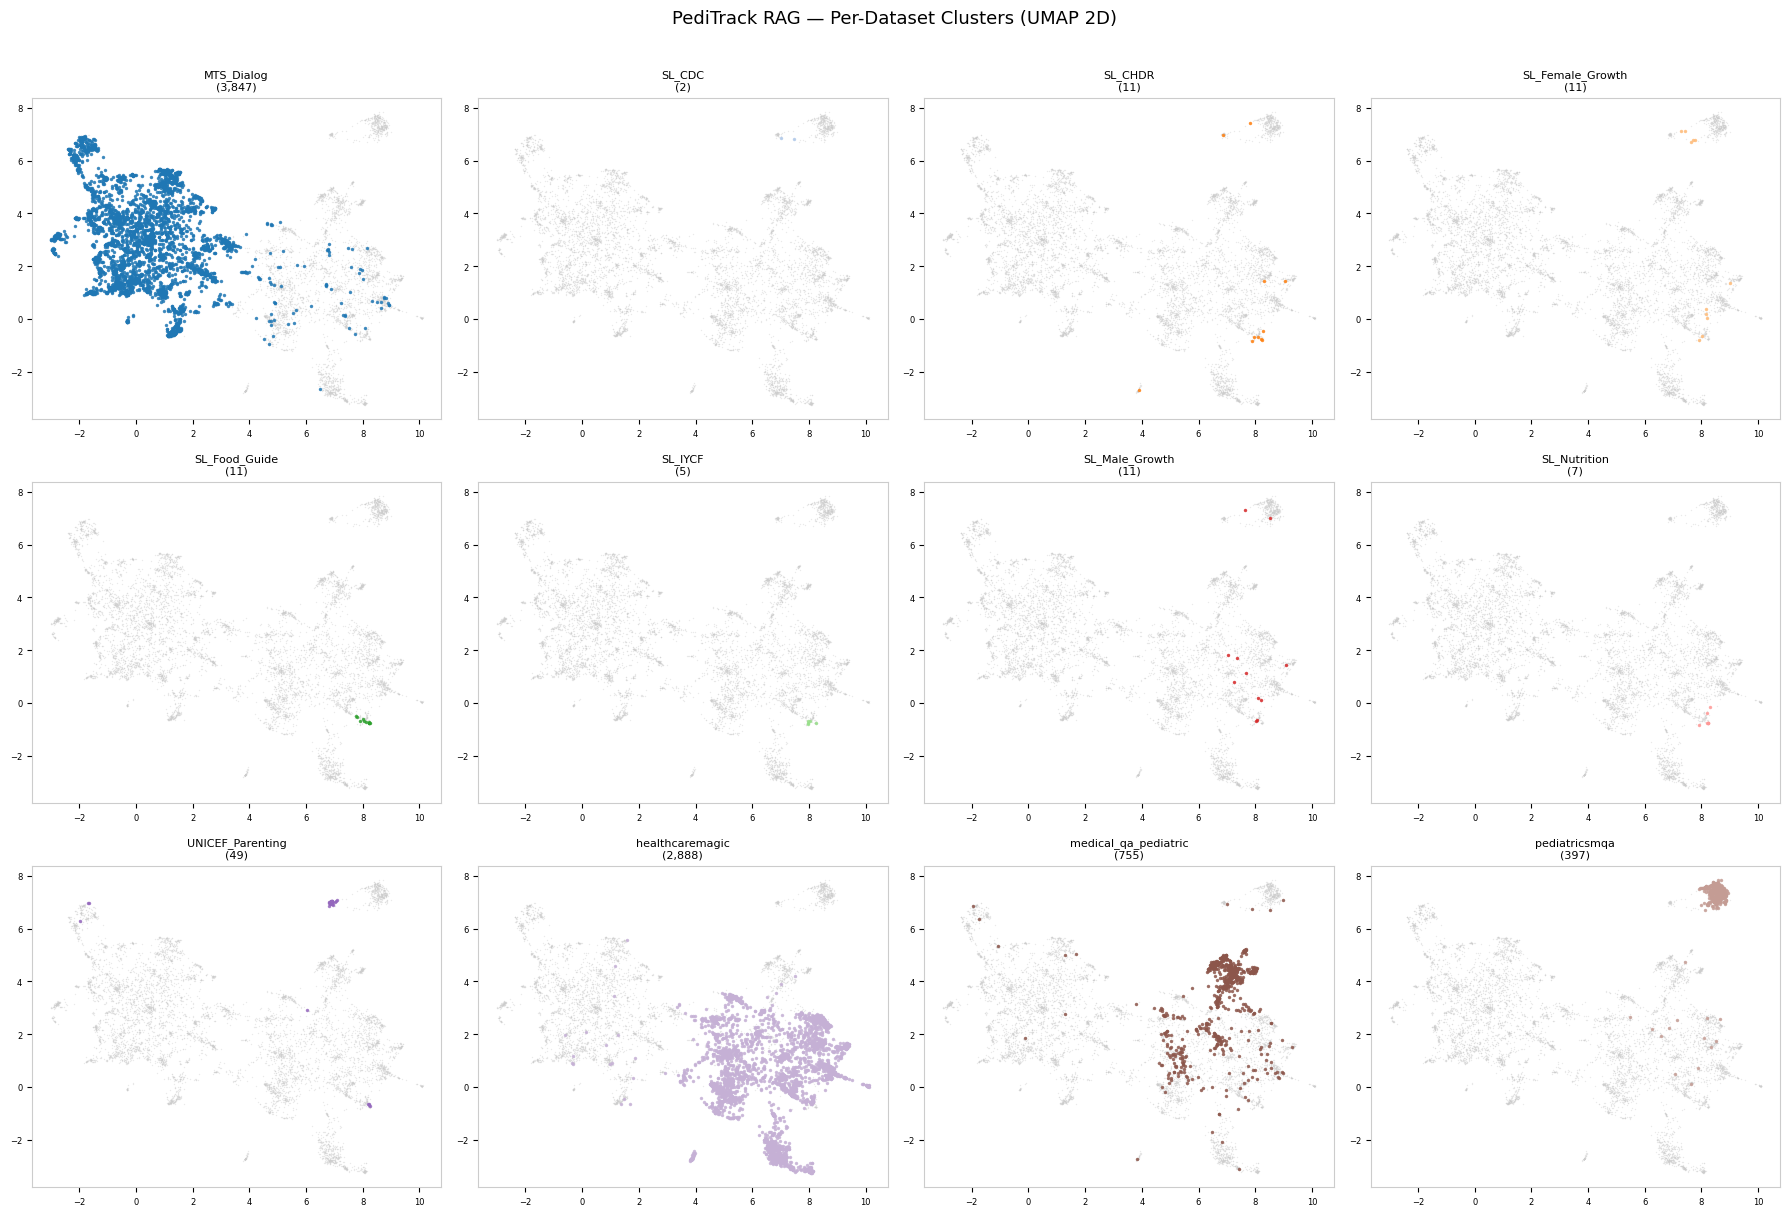

✓ Saved  vector_space_facets.png


In [21]:
import math

n    = len(unique_labels_sorted)
cols = 4
rows = math.ceil(n / cols)

fig2, axes = plt.subplots(rows, cols, figsize=(cols * 4.5, rows * 4))
fig2.patch.set_facecolor('white')
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

# faint background of all points
for ax in axes_flat:
    ax.set_facecolor('white')
    ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
               c='#cccccc', s=1, alpha=0.4, linewidths=0)

for i, lbl in enumerate(unique_labels_sorted):
    ax   = axes_flat[i]
    mask = sample_labels == lbl
    ax.scatter(
        embedding_2d[mask, 0], embedding_2d[mask, 1],
        c=[color_map[lbl]], s=6, alpha=0.85, linewidths=0
    )
    ax.set_title(f"{lbl}\n({mask.sum():,})", color='black', fontsize=8)
    ax.tick_params(colors='black', labelsize=6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#cccccc')

# hide unused subplots
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig2.suptitle('PediTrack RAG — Per-Dataset Clusters (UMAP 2D)',
              color='black', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('vector_space_facets.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✓ Saved  vector_space_facets.png")

**Step 11b — Domain Based Representation**

Domain distribution:
  Clinical & Medical QA                7,887 docs
  Parenting & Child Care                  49 docs
  Nutrition & Feeding                     23 docs
  Growth & Anthropometrics                22 docs
  Child Development                       13 docs


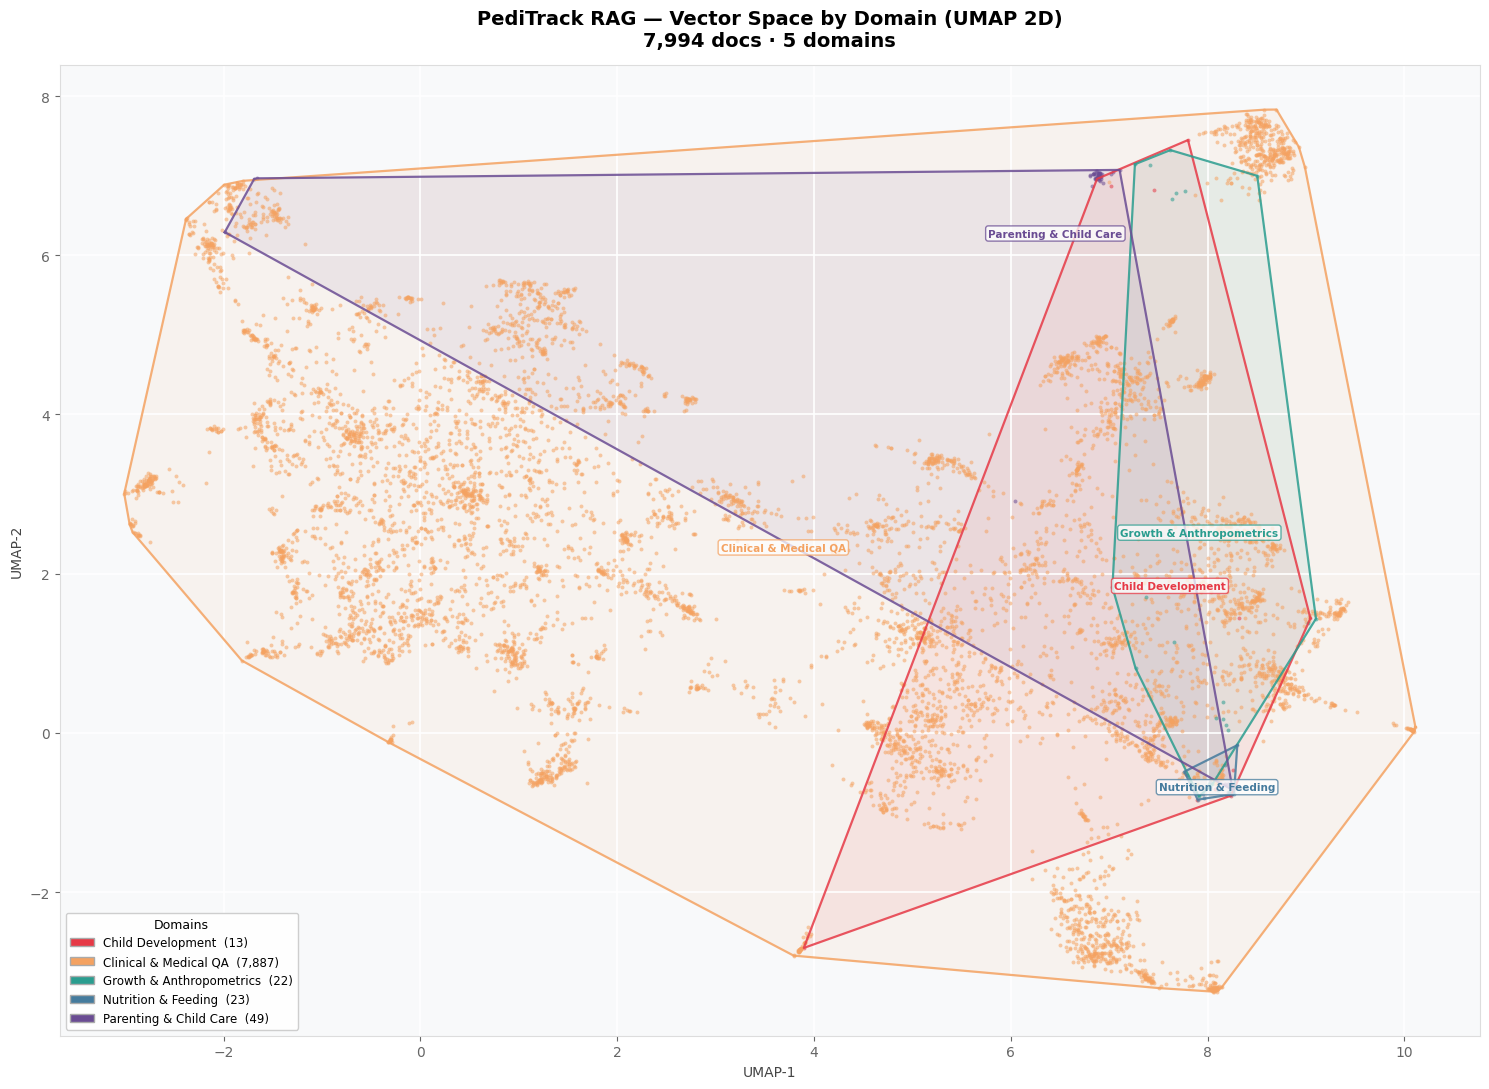

✓ Saved  vector_space_domains.png


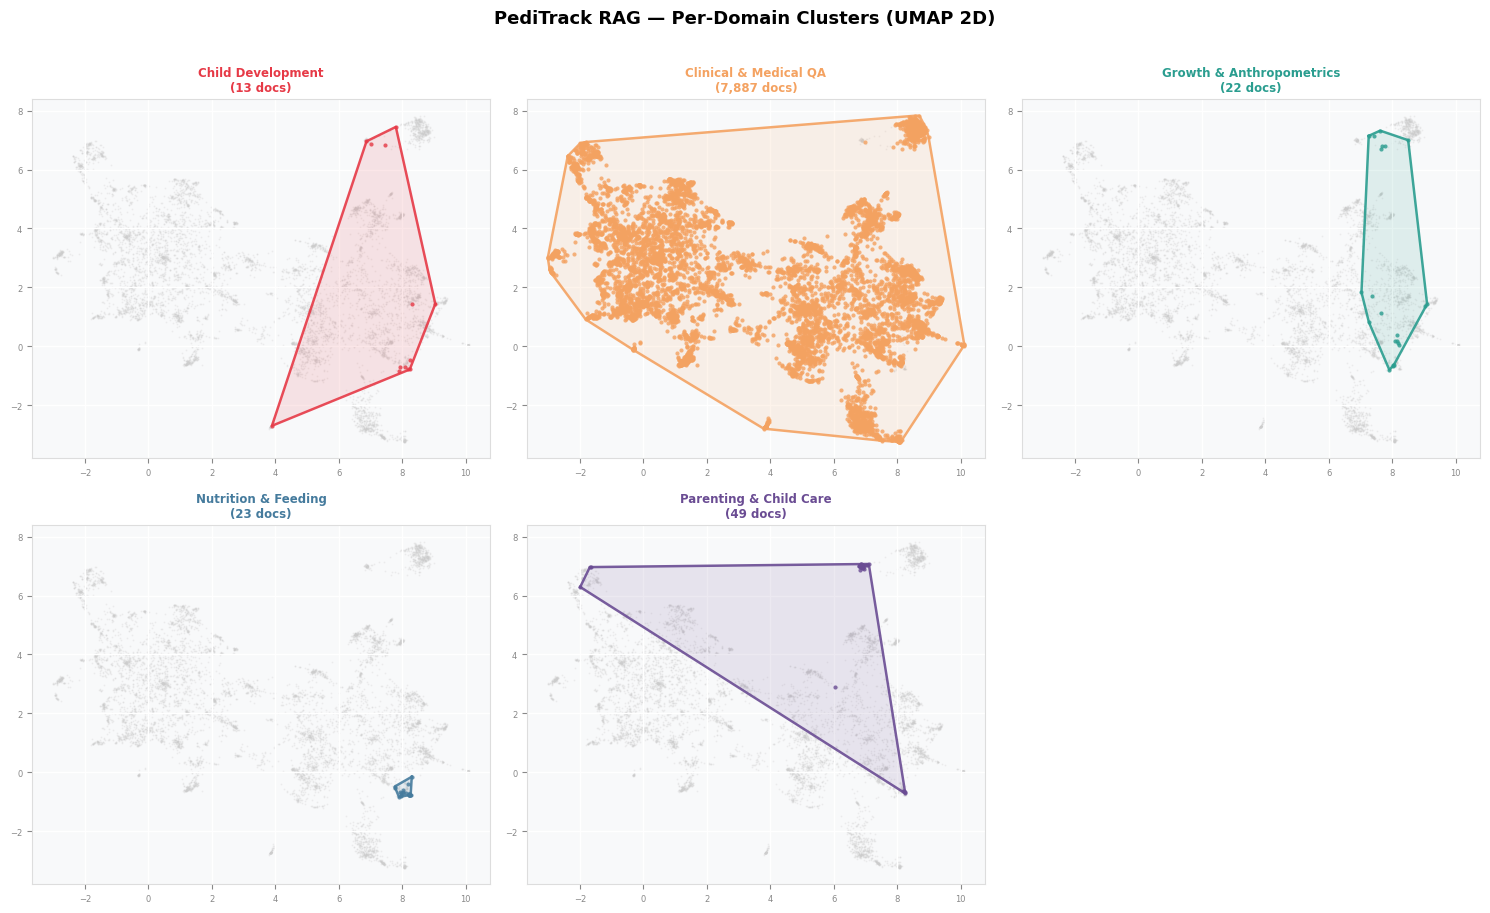

✓ Saved  vector_space_domain_facets.png


In [23]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import seaborn as sns
from collections import Counter
from scipy.spatial import ConvexHull

# ── Domain mapping ────────────────────────────────────────────────────────────
DOMAIN_MAP = {
    'healthcaremagic':   'Clinical & Medical QA',
    'medical_qa':        'Clinical & Medical QA',
    'medicalqa':         'Clinical & Medical QA',
    'pediatricsmqa':     'Clinical & Medical QA',
    'MedDialog_EN':      'Clinical & Medical QA',
    'MedSynth':          'Clinical & Medical QA',
    'MTS_Dialog':        'Clinical & Medical QA',
    'MediTOD':           'Clinical & Medical QA',
    'symptom_checker':   'Disease & Symptoms',
    'disease_db':        'Disease & Symptoms',
    'symptomchecker':    'Disease & Symptoms',
    'SL_IYCF':           'Nutrition & Feeding',
    'SL_Nutrition':      'Nutrition & Feeding',
    'SL_Food_Guide':     'Nutrition & Feeding',
    'SL_Female_Growth':  'Growth & Anthropometrics',
    'SL_Male_Growth':    'Growth & Anthropometrics',
    'SL_CDC':            'Child Development',
    'SL_CHDR':           'Child Development',
    'UNICEF_Parenting':  'Parenting & Child Care',
}

def get_domain(label: str) -> str:
    if label in DOMAIN_MAP:
        return DOMAIN_MAP[label]
    label_lower = label.lower()
    for key, domain in DOMAIN_MAP.items():
        if key.lower() in label_lower or label_lower in key.lower():
            return domain
    return 'Other'

# ── Map labels → domains ──────────────────────────────────────────────────────
domain_labels = np.array([get_domain(lbl) for lbl in sample_labels])
unique_domains = sorted(set(domain_labels))

print("Domain distribution:")
for d, c in sorted(Counter(domain_labels).items(), key=lambda x: -x[1]):
    print(f"  {d:<35} {c:>6,} docs")

# ── Rich distinct colour palette ──────────────────────────────────────────────
COLORS = [
    '#E63946',  # red          — Clinical & Medical QA
    '#F4A261',  # orange       — Disease & Symptoms
    '#2A9D8F',  # teal         — Nutrition & Feeding
    '#457B9D',  # steel blue   — Growth & Anthropometrics
    '#6A4C93',  # purple       — Child Development
    '#F9C74F',  # yellow       — Parenting & Child Care
    '#90BE6D',  # green        — Other
    '#43AA8B',  # mint
]
domain_color_map = {d: COLORS[i % len(COLORS)] for i, d in enumerate(unique_domains)}

# ── ① Overview scatter with convex hull outlines ──────────────────────────────
fig, ax = plt.subplots(figsize=(15, 11))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

# Light grid
ax.grid(True, color='white', linewidth=1.2, zorder=0)

for domain in unique_domains:
    mask = domain_labels == domain
    pts  = embedding_2d[mask]
    col  = domain_color_map[domain]

    # Scatter points
    ax.scatter(
        pts[:, 0], pts[:, 1],
        c=col, s=8, alpha=0.55, linewidths=0, zorder=2
    )

    # Convex hull boundary line (needs ≥ 3 points)
    if len(pts) >= 4:
        try:
            hull = ConvexHull(pts)
            hull_pts = np.append(hull.vertices, hull.vertices[0])   # close the loop
            ax.plot(
                pts[hull_pts, 0], pts[hull_pts, 1],
                color=col, linewidth=1.6, alpha=0.85, zorder=3
            )
            # Soft filled region
            from matplotlib.patches import Polygon as MplPolygon
            poly = MplPolygon(pts[hull.vertices], closed=True,
                              facecolor=col, alpha=0.08, zorder=1)
            ax.add_patch(poly)
        except Exception:
            pass

    # Domain label at centroid
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()
    ax.text(cx, cy, domain, fontsize=7.5, fontweight='bold',
            color=col, ha='center', va='center',
            bbox=dict(facecolor='white', edgecolor=col,
                      boxstyle='round,pad=0.25', alpha=0.75, linewidth=1),
            zorder=5)

# Legend
legend_handles = [
    mpatches.Patch(facecolor=domain_color_map[d], edgecolor='#aaaaaa',
                   label=f"{d}  ({Counter(domain_labels)[d]:,})")
    for d in unique_domains
]
ax.legend(handles=legend_handles, loc='lower left', fontsize=8.5,
          framealpha=0.95, facecolor='white', edgecolor='#cccccc',
          title='Domains', title_fontsize=9)

ax.set_title(
    f'PediTrack RAG — Vector Space by Domain (UMAP 2D)\n'
    f'{len(domain_labels):,} docs · {len(unique_domains)} domains',
    color='black', fontsize=14, pad=14, fontweight='bold'
)
ax.set_xlabel('UMAP-1', color='#444444', fontsize=10)
ax.set_ylabel('UMAP-2', color='#444444', fontsize=10)
ax.tick_params(colors='#666666')
for spine in ax.spines.values():
    spine.set_edgecolor('#dddddd')

plt.tight_layout()
plt.savefig('vector_space_domains.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved  vector_space_domains.png")

# ── ② Per-domain facet grid ───────────────────────────────────────────────────
cols2 = 3
rows2 = math.ceil(len(unique_domains) / cols2)

fig2, axes2 = plt.subplots(rows2, cols2, figsize=(cols2 * 5, rows2 * 4.5))
fig2.patch.set_facecolor('white')
axes2_flat = axes2.flatten() if hasattr(axes2, 'flatten') else [axes2]

for ax in axes2_flat:
    ax.set_facecolor('#f8f9fa')
    ax.grid(True, color='white', linewidth=1.0, zorder=0)
    # All points as light grey background
    ax.scatter(embedding_2d[:, 0], embedding_2d[:, 1],
               c='#cccccc', s=1.5, alpha=0.3, linewidths=0, zorder=1)

for i, domain in enumerate(unique_domains):
    ax   = axes2_flat[i]
    mask = domain_labels == domain
    pts  = embedding_2d[mask]
    col  = domain_color_map[domain]

    ax.scatter(pts[:, 0], pts[:, 1],
               c=col, s=9, alpha=0.8, linewidths=0, zorder=3)

    # Convex hull
    if len(pts) >= 4:
        try:
            hull     = ConvexHull(pts)
            hull_pts = np.append(hull.vertices, hull.vertices[0])
            ax.plot(pts[hull_pts, 0], pts[hull_pts, 1],
                    color=col, linewidth=1.8, alpha=0.9, zorder=4)
            poly = MplPolygon(pts[hull.vertices], closed=True,
                              facecolor=col, alpha=0.12, zorder=2)
            ax.add_patch(poly)
        except Exception:
            pass

    ax.set_title(f"{domain}\n({mask.sum():,} docs)",
                 color=col, fontsize=8.5, fontweight='bold')
    ax.tick_params(colors='#888888', labelsize=6)
    for spine in ax.spines.values():
        spine.set_edgecolor('#dddddd')

for j in range(i + 1, len(axes2_flat)):
    axes2_flat[j].set_visible(False)

fig2.suptitle('PediTrack RAG — Per-Domain Clusters (UMAP 2D)',
              color='black', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('vector_space_domain_facets.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("✓ Saved  vector_space_domain_facets.png")

---
## Step 12: Download Everything

In [18]:
from google.colab import files
import zipfile

with zipfile.ZipFile('vector_store.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write('faiss_index')
    zf.write('metadata.json')
    zf.write('vector_space_2d.png')
    zf.write('vector_space_facets.png')

print("✓ vector_store.zip created")
files.download('vector_store.zip')
print("✓ Download started")

✓ vector_store.zip created


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started


---
## Step 13: Test Retrieval (Optional)

In [19]:
test_queries = [
    "What are the symptoms of fever in children?",
    "Sri Lanka exclusive breastfeeding recommendation",
    "CHDR growth chart underweight baby",
    "Screen time limits for toddlers",
    "Iron deficiency anaemia in infants Sri Lanka",
]

for query in test_queries:
    q_emb = model.encode([query], convert_to_numpy=True).astype('float32')
    dists, idxs = index.search(q_emb, k=3)
    print(f"\n🔍 \"{query}\"")
    for rank, (dist, idx) in enumerate(zip(dists[0], idxs[0]), 1):
        score = 1 / (1 + dist)
        src   = metadata_list[idx]['source']
        text  = metadata_list[idx]['text'][:150]
        print(f"  #{rank} score={score:.3f}  [{src}]  {text}...")


🔍 "What are the symptoms of fever in children?"
  #1 score=0.663  [HealthCareMagic - Medical Consultations]  Patient: If you are a doctor, please answer the medical questions based on the patient's description. My son has had a fever for 24 hours and chills o...
  #2 score=0.657  [HealthCareMagic - Medical Consultations]  Patient: If you are a doctor, please answer the medical questions based on the patient's description. my son is 3years and 10months old,his been havin...
  #3 score=0.651  [HealthCareMagic - Medical Consultations]  Patient: If you are a doctor, please answer the medical questions based on the patient's description. My 12 yr old son 150lbs 5 4 fever

Doctor: Hi......

🔍 "Sri Lanka exclusive breastfeeding recommendation"
  #1 score=0.571  [SL_Male_Growth]  Gender: male | Topics: exclusive breastfeeding, nutritional base, boys | Duration: Exclusive breastfeeding is mandatory for the first 180 days to prov...
  #2 score=0.562  [SL_Female_Growth]  Gender: female | Topics:

---
## Done!

`vector_store.zip` contains:
- `faiss_index` — FAISS binary index (all vectors)
- `metadata.json` — text + source + metadata for every document
- `vector_space_2d.png` — 2D UMAP overview of the entire vector space
- `vector_space_facets.png` — per-dataset facet grid

**After downloading:**
1. Extract to `services/peditrack-rag-service/vector_store/`
2. Restart the RAG service — it auto-loads the new index on startup
3. Verify with `curl http://localhost:3002/api/rag/stats`